In [1]:
import sys
sys.path.append("..")

from src.data import fetch_prices, compute_returns, compute_rolling_volatility
from src.regime import build_hmm_features, fit_hmm, label_regimes, plot_regimes
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
nifty = fetch_prices(tickers="^NSEI", start="2015-01-01")
nifty_returns = compute_returns(nifty)

[*********************100%***********************]  1 of 1 completed


In [3]:
prices = fetch_prices()
returns = compute_returns(prices)
print("Price shape:", prices.shape)
print("Returns shape:", returns.shape)

[*********************100%***********************]  10 of 10 completed

Price shape: (2842, 10)
Returns shape: (2841, 10)


In [4]:
ew_return = returns.mean(axis=1)
ew_price = (1 + ew_return).cumprod()  

In [5]:
features = build_hmm_features(ew_return)
model, hidden_states = fit_hmm(features, n_states=4)

In [6]:
regime_series, label_map = label_regimes(model, hidden_states, features)
print("\nRegime distribution:")
print(regime_series.value_counts())


Regime distribution:
regime
Bull           1098
High-Vol        898
Neutral         720
Bear/Crisis     105
Name: count, dtype: int64


In [7]:
print("\nSample regimes around COVID crash:")
print(regime_series["2020-01":"2020-06"])


Sample regimes around COVID crash:
Date
2020-01-01       Bull
2020-01-02       Bull
2020-01-03       Bull
2020-01-06       Bull
2020-01-07       Bull
               ...   
2020-06-24    Neutral
2020-06-25    Neutral
2020-06-26    Neutral
2020-06-29    Neutral
2020-06-30    Neutral
Name: regime, Length: 122, dtype: str


In [8]:
print("ew_price:", ew_price.shape, ew_price.index.min(), ew_price.index.max())
print("regime_series:", regime_series.shape, regime_series.index.min(), regime_series.index.max())
print(ew_price.head())
print(regime_series.head())

ew_price: (2841,) 2015-01-02 00:00:00 2026-07-03 00:00:00
regime_series: (2821,) 2015-02-02 00:00:00 2026-07-03 00:00:00
Date
2015-01-02    1.007823
2015-01-05    1.006640
2015-01-06    0.981066
2015-01-07    0.980836
2015-01-08    0.990754
dtype: float64
Date
2015-02-02    High-Vol
2015-02-03    High-Vol
2015-02-04    High-Vol
2015-02-05    High-Vol
2015-02-06    High-Vol
Name: regime, dtype: str


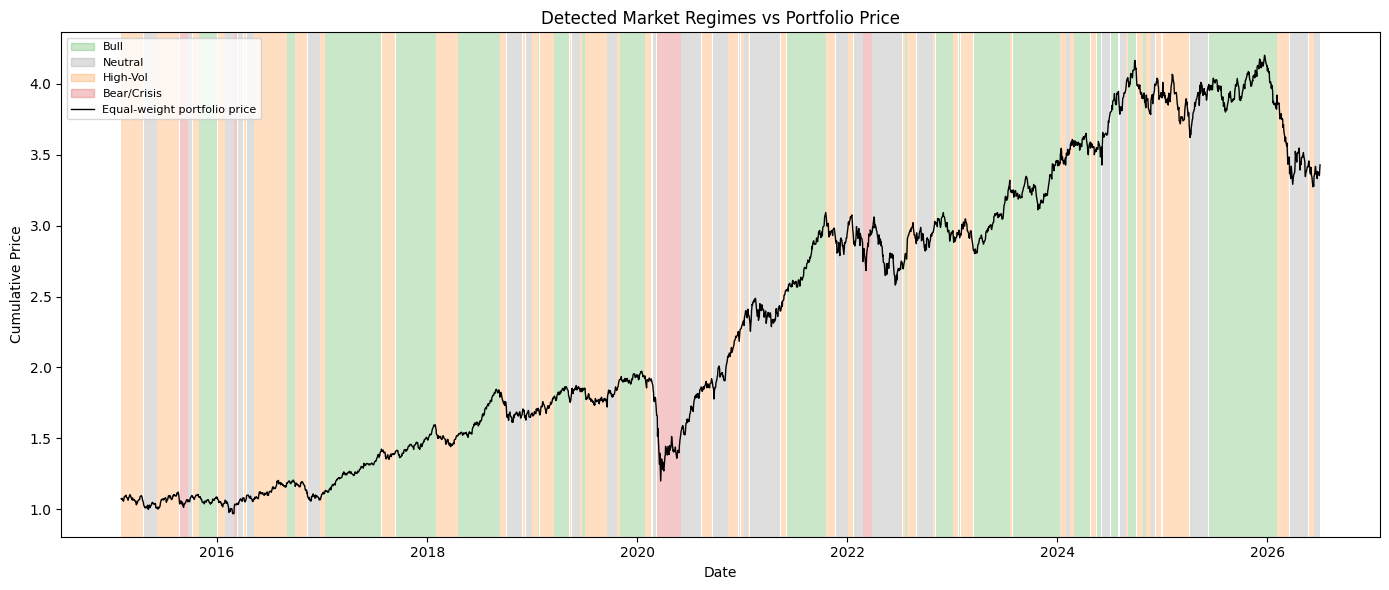

Plot saved to D:\quantrisk\data\regime_plot.png


In [9]:
plot_regimes(ew_price, regime_series)

In [10]:
from src.data import fetch_prices

prices = fetch_prices()
print(prices.shape)
print(prices.columns)

[*********************100%***********************]  10 of 10 completed

(2842, 10)
Index(['BAJFINANCE.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'INFY.NS', 'ITC.NS',
       'MARUTI.NS', 'RELIANCE.NS', 'SUNPHARMA.NS', 'TCS.NS', 'WIPRO.NS'],
      dtype='str', name='Ticker')


In [11]:
print(regime_series["2020-03"])

Date
2020-03-02        Neutral
2020-03-03        Neutral
2020-03-04        Neutral
2020-03-05        Neutral
2020-03-06        Neutral
2020-03-09    Bear/Crisis
2020-03-11    Bear/Crisis
2020-03-12    Bear/Crisis
2020-03-13    Bear/Crisis
2020-03-16    Bear/Crisis
2020-03-17    Bear/Crisis
2020-03-18    Bear/Crisis
2020-03-19    Bear/Crisis
2020-03-20    Bear/Crisis
2020-03-23    Bear/Crisis
2020-03-24    Bear/Crisis
2020-03-25    Bear/Crisis
2020-03-26    Bear/Crisis
2020-03-27    Bear/Crisis
2020-03-30    Bear/Crisis
2020-03-31    Bear/Crisis
Name: regime, dtype: str


In [12]:
regime_series.groupby(regime_series.dt.year if hasattr(regime_series, 'dt') else regime_series.index.year).value_counts(normalize=True)

Date  regime     
2015  High-Vol       0.537778
      Neutral        0.186667
      Bull           0.182222
      Bear/Crisis    0.093333
2016  High-Vol       0.565041
      Neutral        0.329268
      Bull           0.073171
      Bear/Crisis    0.032520
2017  Bull           0.842742
      High-Vol       0.157258
2018  Bull           0.504065
      High-Vol       0.284553
      Neutral        0.211382
2019  High-Vol       0.477366
      Bull           0.349794
      Neutral        0.172840
2020  Neutral        0.406375
      High-Vol       0.290837
      Bear/Crisis    0.219124
      Bull           0.083665
2021  Neutral        0.439516
      Bull           0.375000
      High-Vol       0.185484
2022  Neutral        0.540323
      High-Vol       0.193548
      Bull           0.181452
      Bear/Crisis    0.084677
2023  Bull           0.795918
      High-Vol       0.204082
2024  Bull           0.422764
      High-Vol       0.345528
      Neutral        0.231707
2025  Bull           0

In [13]:
print(regime_series.value_counts(normalize=True))

regime
Bull           0.389224
High-Vol       0.318327
Neutral        0.255229
Bear/Crisis    0.037221
Name: proportion, dtype: float64


In [14]:
from src.risk import sharpe_ratio, max_drawdown, sortino_ratio

print("Sharpe:", sharpe_ratio(ew_return))
dd = max_drawdown(ew_price)
print("Max Drawdown:", dd["max_drawdown"])
print("Peak:", dd["peak_date"], "-> Trough:", dd["trough_date"])
print("Sortino:", sortino_ratio(ew_return))

Sharpe: 0.7526838337426541
Max Drawdown: -0.3922405395350984
Peak: 2020-01-17 00:00:00 -> Trough: 2020-03-23 00:00:00
Sortino: 0.9194666578358704


In [15]:
from src.risk import fit_garch, forecast_volatility

garch_fit = fit_garch(ew_return)
vol_forecast = forecast_volatility(garch_fit, horizon=5)
print("Next 5-day volatility forecast (decimal):", vol_forecast)

GARCH(1,1) fitted — omega=0.0242, alpha=0.0626, beta=0.9089, persistence (alpha+beta)=0.9715
Next 5-day volatility forecast (decimal): [0.00883825 0.00884937 0.00886017 0.00887064 0.00888081]


In [16]:
from src.risk import historical_cvar, parametric_cvar

hist_cvar = historical_cvar(ew_return, confidence_level=0.95)
print("Historical 95% CVaR (daily):", hist_cvar)

garch_vol = forecast_volatility(garch_fit, horizon=1)[0]
param_cvar = parametric_cvar(mean_return=ew_return.mean(), volatility=garch_vol,
                               confidence_level=0.95, dist="t", nu=5)
print("Parametric (GARCH-based) 95% CVaR (daily):", param_cvar)

Historical 95% CVaR (daily): -0.023593560863478222
Parametric (GARCH-based) 95% CVaR (daily): -0.02505675197650632


In [17]:
from src.risk import get_fitted_nu

fitted_nu = get_fitted_nu(garch_fit)
print("Fitted nu:", fitted_nu)

param_cvar_v2 = parametric_cvar(mean_return=ew_return.mean(), volatility=garch_vol,
                                  confidence_level=0.95, dist="t", nu=fitted_nu)
print("Parametric CVaR (fitted nu):", param_cvar_v2)

Fitted nu: 6.904015554876477
Parametric CVaR (fitted nu): -0.022528890443719876


In [18]:
from src.risk import calculate_beta
beta = calculate_beta(ew_return, nifty_returns.iloc[:, 0] if hasattr(nifty_returns, 'columns') else nifty_returns)
print("Portfolio beta vs Nifty 50:", beta)

Portfolio beta vs Nifty 50: 0.9380951762191816
